In [1]:
import pandas as pd
import numpy as np

# Load the dataset
# Note: if your file is in the 'data' folder, use the relative path
df = pd.read_excel('../data/online_retail_II.xlsx')

# Show the first 5 rows to confirm it loaded
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Check for missing values in each column
print(df.isnull().sum())

# Drop rows where Customer ID is missing
df.dropna(subset=['Customer ID'], inplace=True)

# Verify they are gone
print(f"Remaining rows: {df.shape[0]}")

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Remaining rows: 417534


In [3]:
# Remove rows where Invoice contains 'C'
df = df[~df['Invoice'].astype(str).str.contains('C')]

In [4]:
# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [5]:
# Calculate Total Sum
df['TotalSum'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
# Calculate the difference
original_count = 1048575 # This varies based on your specific file version
current_count = df.shape[0]
removed_count = original_count - current_count

print(f"Original Row Count: {original_count}")
print(f"Cleaned Row Count: {current_count}")
print(f"Total Rows Removed: {removed_count}")
print(f"Percentage of Data Retained: {round((current_count / original_count) * 100, 2)}%")

Original Row Count: 1048575
Cleaned Row Count: 407664
Total Rows Removed: 640911
Percentage of Data Retained: 38.88%


In [7]:
import datetime as dt

# Find the last date in the dataset and add one day
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Analysis Snapshot Date: {snapshot_date}")

Analysis Snapshot Date: 2010-12-10 20:01:00


In [8]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': lambda x: x.nunique(),
    'TotalSum': 'sum'
})

# Rename the columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [9]:
rfm['Recency'] = rfm['Recency'].astype(int)

In [10]:
# Create Recency scores (5 is best/most recent)
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Create Frequency scores (5 is best/most frequent)
# Note: We use 'rank(method="first")' because e-commerce data often has many customers with the same frequency
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

# Create Monetary scores (5 is best/highest spender)
rfm["monetary_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine Recency and Frequency to create a segment map
# (Monetary is often used for secondary filtering)
rfm["RFM_SCORE"] = (rfm['recency_score'].astype(str) + 
                    rfm['frequency_score'].astype(str))

rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,25
12347.0,3,2,1323.32,5,2,4,52
12348.0,74,1,222.16,2,1,1,21
12349.0,43,3,2671.14,3,3,5,33
12351.0,11,1,300.93,5,1,2,51


In [11]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)
rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,5,2,25,cant_loose
12347.0,3,2,1323.32,5,2,4,52,potential_loyalists
12348.0,74,1,222.16,2,1,1,21,hibernating
12349.0,43,3,2671.14,3,3,5,33,need_attention
12351.0,11,1,300.93,5,1,2,51,new_customers


C:\Users\Devin Weerassinghe\AppData\Local\Temp\ipykernel_27088\3307067811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='segment', order=rfm['segment'].value_counts().index, palette='viridis')


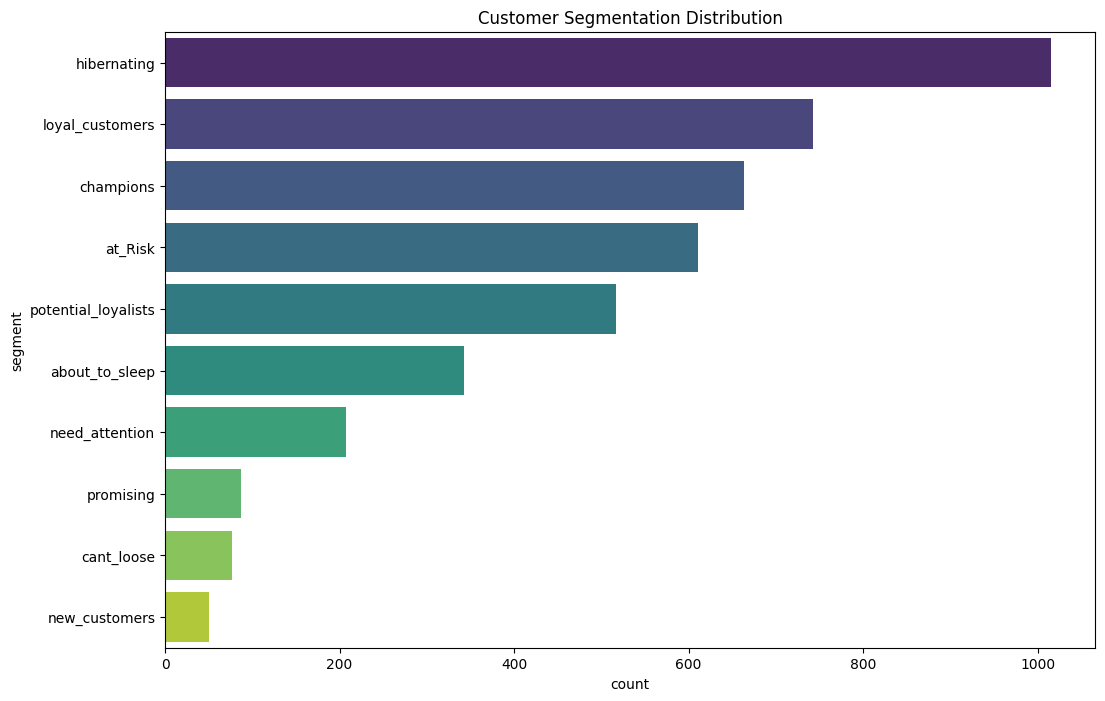

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=rfm, y='segment', order=rfm['segment'].value_counts().index, palette='viridis')
plt.title('Customer Segmentation Distribution')
plt.show()